In [1]:
import seaborn as sns
import pandas as pd
from matplotlib import pyplot as plt
from lib.common import *
from lib.boat import boat

In [2]:
boatname = 'Petsamo'

sails = ['Nr.1', 'Nr.2', 'Nr.3', 'Stormjib', 'Mainsail', 'Genaker', 'Mizzen', 'Mizzen staysail']
points_of_sail={
    'close haul': list(range(0,37)),
    'close reach': list(range(36,73)),
    'beam': list(range(72,109)),
    'broad reach': list(range(108,145)),
    'run': list(range(144,181))
}
yesmark = 'x'
nomark = '-'

In [3]:
df=boat(boatname).get_sail_data()
df.dropna(inplace=True)
df['heel']=df['heel'].apply(lambda x: int(abs(x)))
df['twa']=df['twa'].apply(lambda x: abs(x))
df=df[df['spd']!=0]
df['spd / tws']=round(df['spd']/df['tws'],2)
df.reset_index(inplace=True, drop=True)
df.head()

,tws,spd,twd,twa,sails,heel,spd / tws
0,13.8,6.7,134,86,"[Mainsail, Mizzen, Mizzen staysail, Nr.2]",34,0.49
1,12.3,3.4,132,127,"[Mainsail, Mizzen, Nr.2]",25,0.28
2,13.8,6.7,133,86,"[Mainsail, Mizzen, Mizzen staysail, Nr.2]",32,0.49
3,13.8,6.6,133,86,"[Mainsail, Mizzen, Mizzen staysail, Nr.2]",35,0.48
4,13.8,5.8,133,164,"[Mainsail, Mizzen, Genaker, Mizzen staysail, N...",15,0.42


#### Expand sail data:

In [4]:
for i in range(len(df.index)):
    for sail in sails:
        if sail in df.iloc[i]['sails']:
            mark = yesmark
        else:
            mark = nomark
        df.at[i, sail] = mark
        
df.drop(['sails'], axis=1, inplace=True)
df.head()    

,tws,spd,twd,twa,heel,spd / tws,Nr.1,Nr.2,Nr.3,Stormjib,Mainsail,Genaker,Mizzen,Mizzen staysail
0,13.8,6.7,134,86,34,0.49,-,x,-,-,x,-,x,x
1,12.3,3.4,132,127,25,0.28,-,x,-,-,x,-,x,-
2,13.8,6.7,133,86,32,0.49,-,x,-,-,x,-,x,x
3,13.8,6.6,133,86,35,0.48,-,x,-,-,x,-,x,x
4,13.8,5.8,133,164,15,0.42,-,-,x,-,x,x,x,x


In [5]:
df['pos'] = [name for i in df.index for name in points_of_sail if df.iloc[i]['twa'] in points_of_sail[name]]
df

,tws,spd,twd,twa,heel,spd / tws,Nr.1,Nr.2,Nr.3,Stormjib,Mainsail,Genaker,Mizzen,Mizzen staysail,pos
0,13.8,6.7,134,86,34,0.49,-,x,-,-,x,-,x,x,beam
1,12.3,3.4,132,127,25,0.28,-,x,-,-,x,-,x,-,broad reach
2,13.8,6.7,133,86,32,0.49,-,x,-,-,x,-,x,x,beam
3,13.8,6.6,133,86,35,0.48,-,x,-,-,x,-,x,x,beam
4,13.8,5.8,133,164,15,0.42,-,-,x,-,x,x,x,x,run
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101,12.2,5.3,302,45,26,0.43,-,x,-,-,x,-,x,-,close reach
102,14.3,5.5,314,45,27,0.38,-,x,-,-,x,-,x,-,close reach
103,15.2,5.3,316,45,34,0.35,-,x,-,-,x,-,x,-,close reach
104,15.4,5.3,316,45,35,0.34,-,x,-,-,x,-,x,-,close reach


[Text(0.5, 1.0, 'spd to tws')]

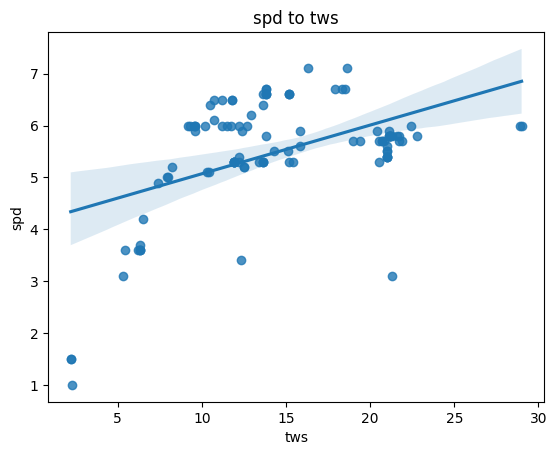

In [6]:
sns.regplot(df, x='tws', y='spd').set(title='spd to tws')

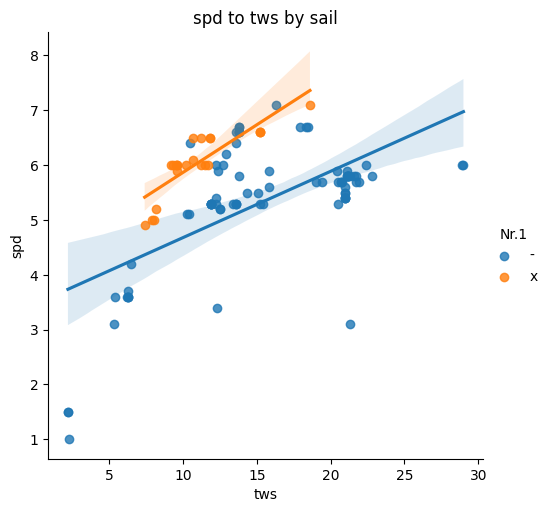

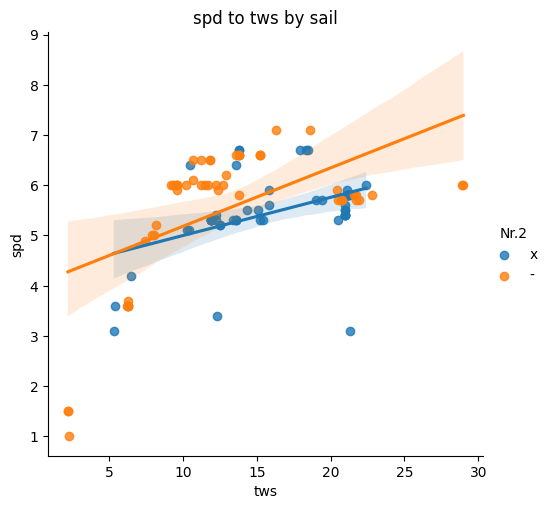

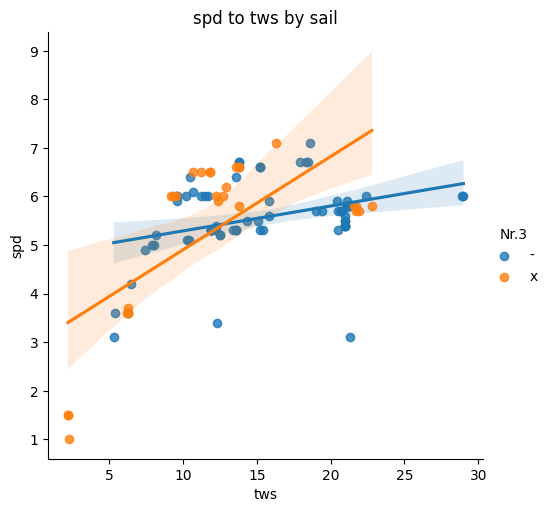

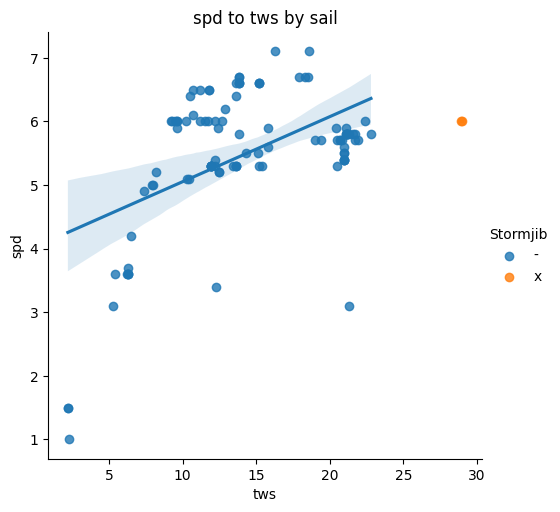

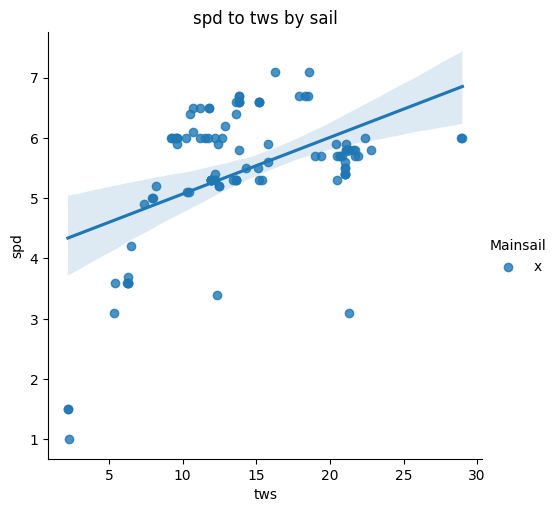

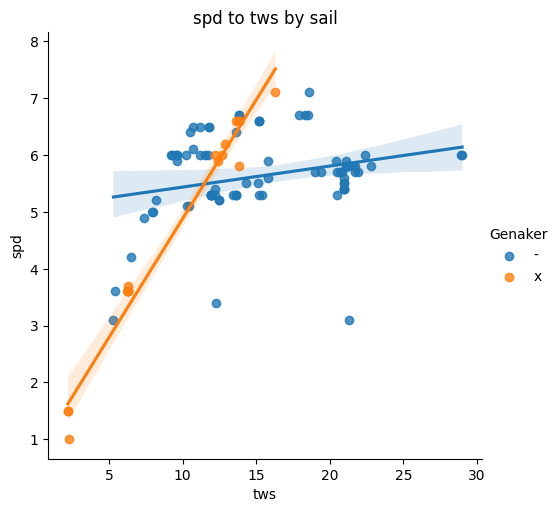

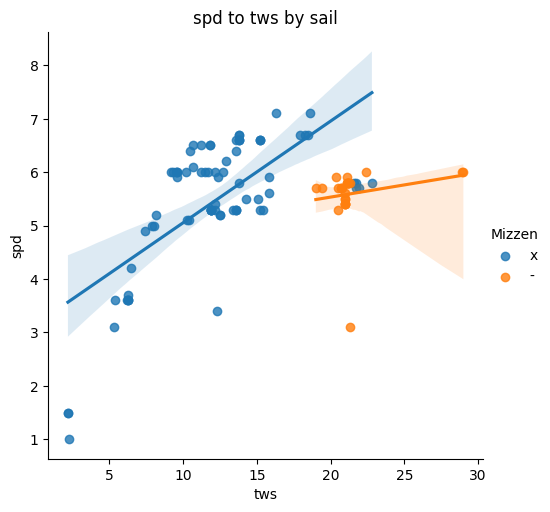

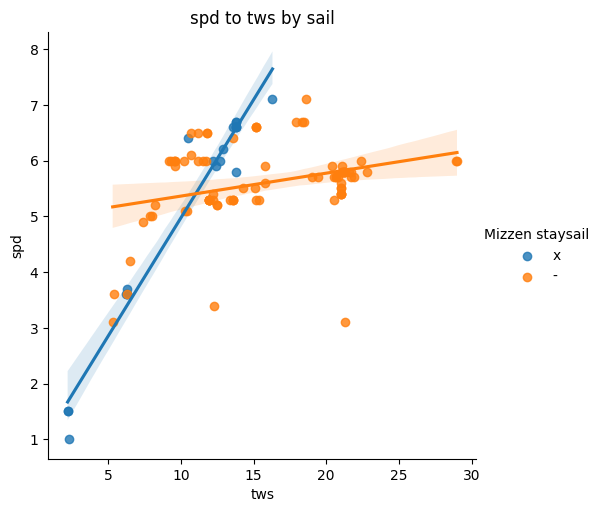

In [7]:
for sail in sails:
    sns.lmplot(df, x='tws', y='spd', hue=sail).set(title='spd to tws by sail')

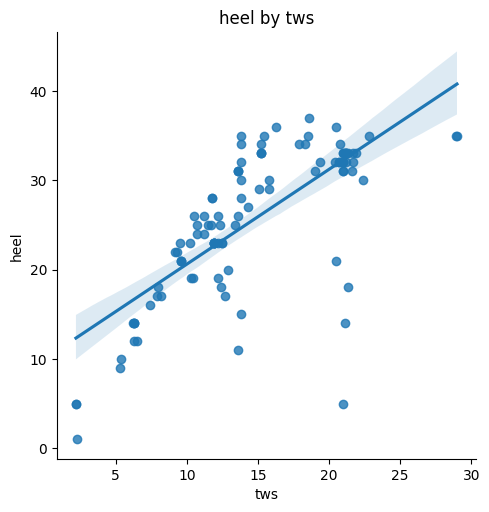

In [8]:
sns.lmplot(df, x='tws', y='heel').set(title='heel by tws')

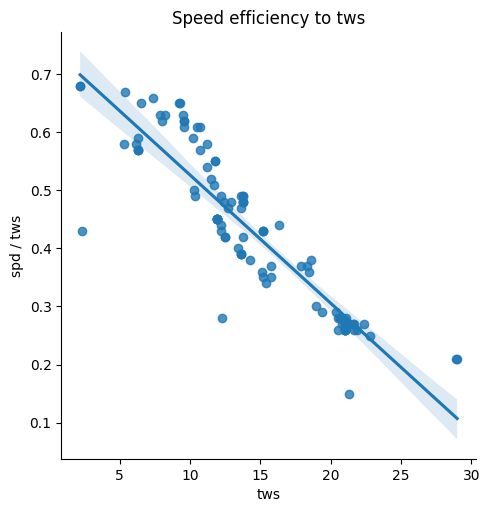

In [9]:
sns.lmplot(df, x='tws', y='spd / tws').set(title='Speed efficiency to tws')

In [10]:
df_pos=df.sort_values('twa')[['pos'] + sails].reset_index(drop=True)
df_pos

,pos,Nr.1,Nr.2,Nr.3,Stormjib,Mainsail,Genaker,Mizzen,Mizzen staysail
0,close haul,-,x,-,-,x,-,-,-
1,close reach,-,x,-,-,x,-,-,-
2,close reach,-,x,-,-,x,-,x,-
3,close reach,-,-,-,-,x,-,-,-
4,close reach,-,-,-,-,x,-,-,-
...,...,...,...,...,...,...,...,...,...
101,run,-,-,x,-,x,x,x,x
102,run,-,-,x,-,x,x,x,x
103,run,-,-,x,-,x,x,x,x
104,run,-,-,x,-,x,x,x,x


In [11]:
df_pos=df_pos.replace(yesmark, 1)
df_pos=df_pos.replace(nomark, 0)
df_pos

,pos,Nr.1,Nr.2,Nr.3,Stormjib,Mainsail,Genaker,Mizzen,Mizzen staysail
0,close haul,0,1,0,0,1,0,0,0
1,close reach,0,1,0,0,1,0,0,0
2,close reach,0,1,0,0,1,0,1,0
3,close reach,0,0,0,0,1,0,0,0
4,close reach,0,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...
101,run,0,0,1,0,1,1,1,1
102,run,0,0,1,0,1,1,1,1
103,run,0,0,1,0,1,1,1,1
104,run,0,0,1,0,1,1,1,1


In [12]:
df_plot=df_pos.groupby('pos').sum()
df_plot

,Nr.1,Nr.2,Nr.3,Stormjib,Mainsail,Genaker,Mizzen,Mizzen staysail
pos,,,,,,,,
beam,14,7,7,0,21,0,21,4
broad reach,0,1,10,0,11,10,11,10
close haul,0,1,0,0,1,0,0,0
close reach,9,45,5,2,66,0,40,0
run,0,1,6,0,7,6,7,6


[Text(0.5, 1.0, 'Sail types usage by point of sail')]

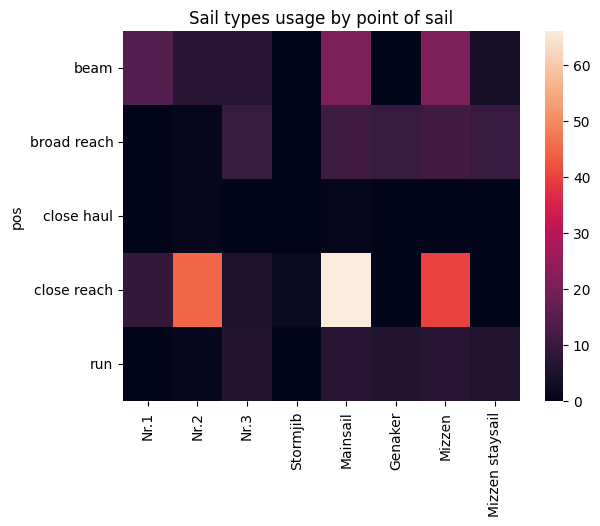

In [13]:
sns.heatmap(df_plot).set(title='Sail types usage by point of sail')

[Text(0.5, 1.0, 'Points of sail frequency')]

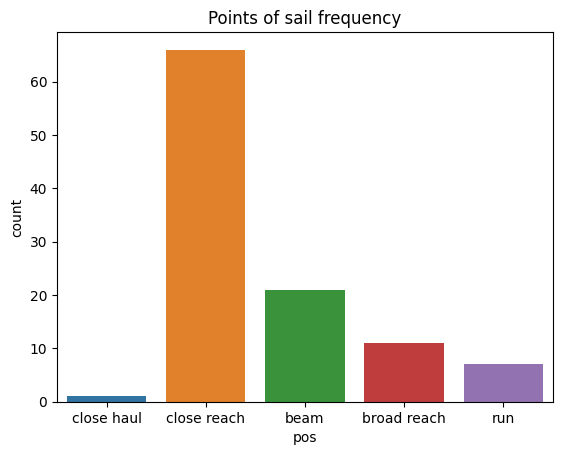

In [14]:
sns.countplot(df_pos, x='pos').set(title='Points of sail frequency')